In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/retail_sales.csv')

In [ ]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

'''converting to datetime to later work in ARIMA as
it expects a datetime format'''

df = df.set_index('date').sort_index()

#setting index for time-series forecasting

In [ ]:
df.isnull().sum()

,0
store_id,0
item_id,0
sales,0
price,0
promo,0
weekday,0
month,0
inventory,0
replenishment,0


In [ ]:
import matplotlib.pyplot as plt

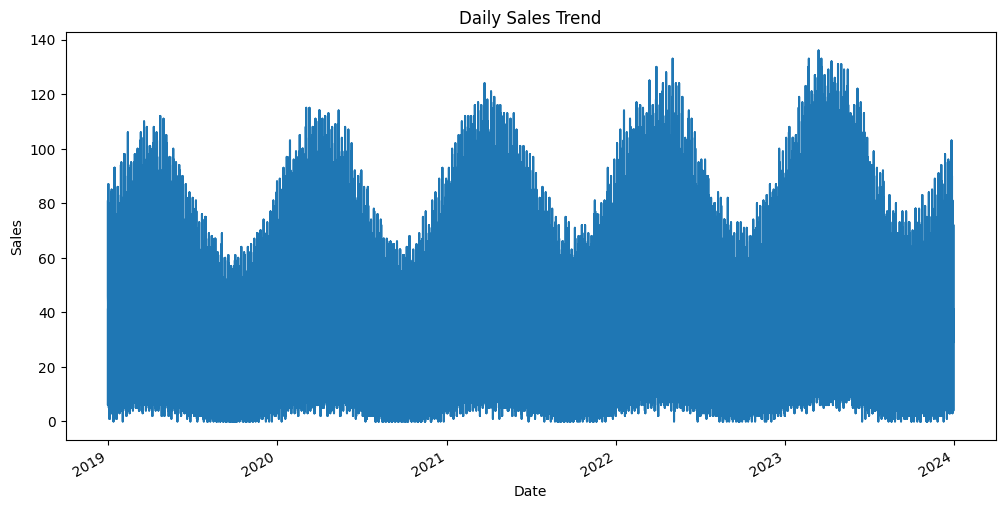

In [ ]:
df['sales'].plot(figsize=(12,6), title="Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

<Axes: title={'center': 'Weekly Sales Trend'}, xlabel='date'>

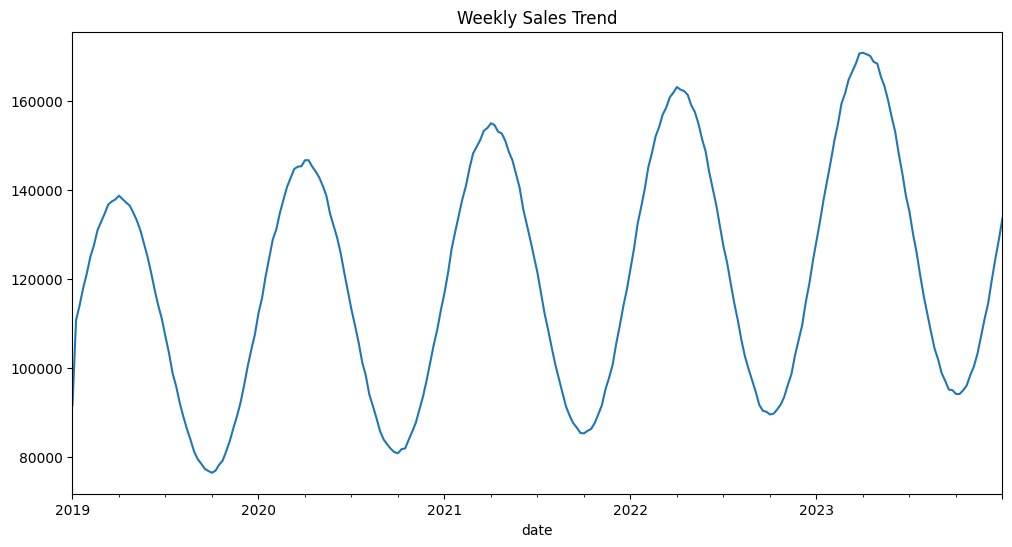

In [ ]:
df['sales'].resample('W').sum().plot(figsize=(12,6),title="Weekly Sales Trend")

/tmp/ipykernel_2768/2470542425.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['sales'].resample('M').sum().plot(figsize=(12,6),title="Monthly Sales Trend")


<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='date'>

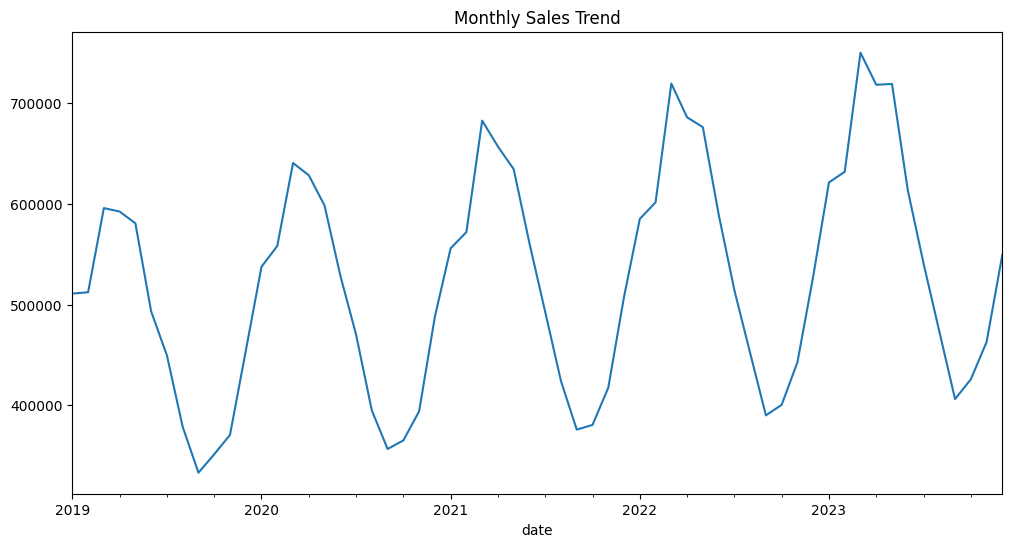

In [ ]:
df['sales'].resample('M').sum().plot(figsize=(12,6),title="Monthly Sales Trend")

<Axes: title={'center': 'Sales with Moving Averages'}, xlabel='date'>

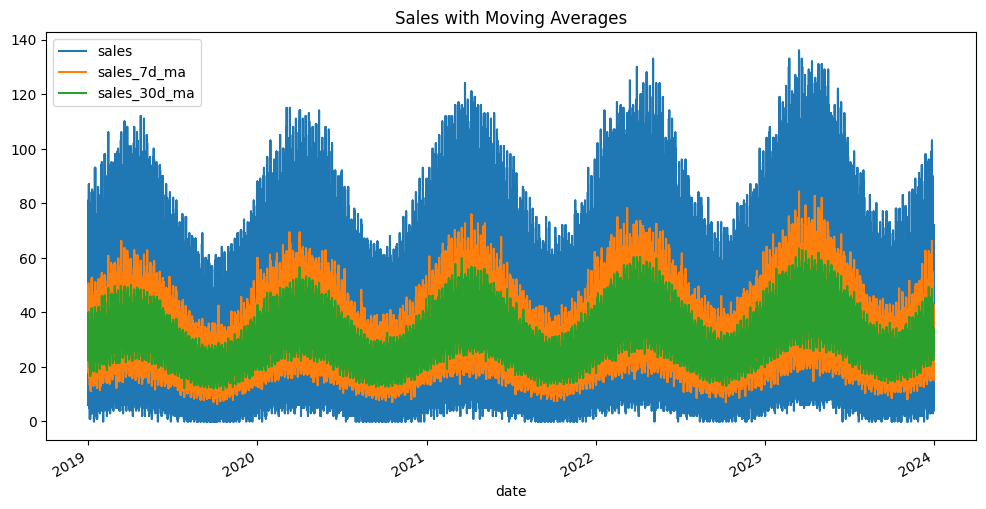

In [ ]:
df['sales_7d_ma'] = df['sales'].rolling(window=7).mean()
df['sales_30d_ma'] = df['sales'].rolling(window=30).mean()
df[['sales','sales_7d_ma','sales_30d_ma']].plot(figsize=(12,6), title="Sales with Moving Averages")

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


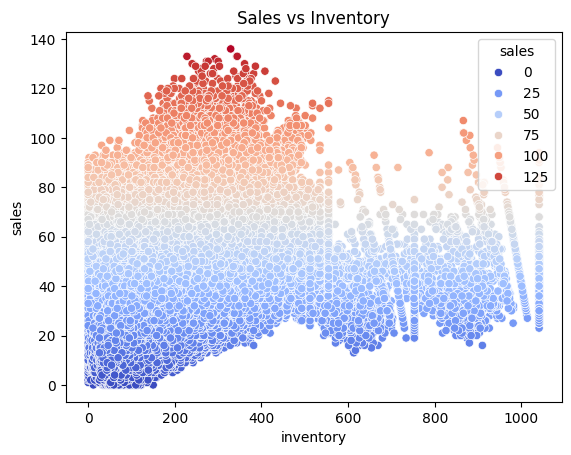

Correlation: 0.498668215667382


In [ ]:
import seaborn as sns

sns.scatterplot(x='inventory', y='sales', data=df,hue='sales', palette='coolwarm')
plt.title("Sales vs Inventory")
plt.show()

print("Correlation:", df['sales'].corr(df['inventory']))

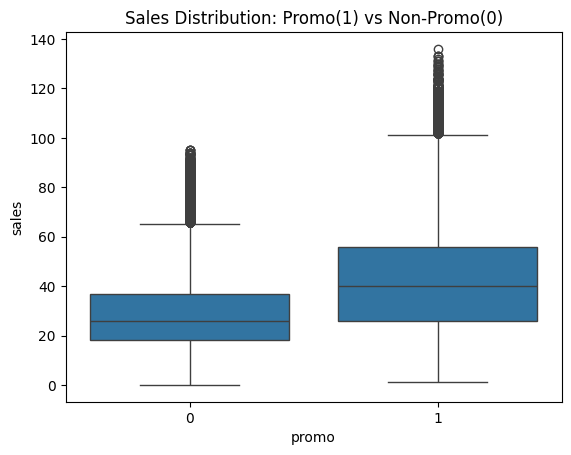

In [ ]:
sns.boxplot(x='promo', y='sales', data=df)
plt.title("Sales Distribution: Promo(1) vs Non-Promo(0)")
plt.show()

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


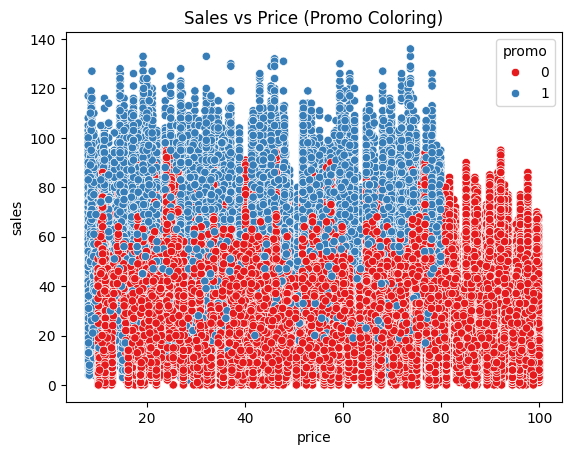

In [ ]:
sns.scatterplot(x='price', y='sales', data=df, hue='promo', palette='Set1')
plt.title("Sales vs Price (Promo Coloring)")
plt.show()

In [ ]:
train = df.loc[:'2023-09-30']
test = df.loc['2023-10-01':]

#sampling to weekly for avoiding memory crash
train_series = train['sales'].resample('W').sum() #sampling
test_series  = test['sales'].resample('W').sum()

train_exog = train[['price','promo']].resample('W').mean()
test_exog  = test[['price','promo']].resample('W').mean()

In [ ]:
!pip install pmdarima
from pmdarima import auto_arima

# Auto ARIMA with exogenous regressors
auto_model = auto_arima(train_series, exogenous=train_exog,
                        seasonal=False, stepwise=True,
                        suppress_warnings=True)

print(auto_model.summary())

forecast_arimax = auto_model.predict(n_periods=len(test_series),
                                     exogenous=test_exog)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 10.6 MB/s eta 0:00:00
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  248
Model:               SARIMAX(3, 0, 2)   Log Likelihood               -2154.299
Date:                Thu, 10 Sep 2026   AIC                           4320.599
Time:                        17:53:35   BIC                           4341.679
Sample:                    01-06-2019   HQIC                          4329.085
                         - 10-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          2.8895      0.014    199.571      0.000       2.861       2.918
ar.L2         -2.7952      0.029    -97.344      0

In [ ]:
!pip install prophet
from prophet import Prophet

# Prophet requires ds (date) and y (target)
# Construct prophet_df using the weekly aggregated train_series and train_exog
prophet_df = pd.DataFrame({
    'ds': train_series.index,
    'y': train_series.values
})
prophet_df['price'] = train_exog['price'].values
prophet_df['promo'] = train_exog['promo'].values

model = Prophet()
model.add_regressor('price')
model.add_regressor('promo')
model.fit(prophet_df)

# For the 'future' DataFrame, which Prophet uses for predictions
# It needs 'ds' (dates to predict) and the future values of the regressors.
future = pd.DataFrame({
    'ds': test_series.index
})
future['price'] = test_exog['price'].values
future['promo'] = test_exog['promo'].values

forecast_prophet = model.predict(future)
forecast_sales = forecast_prophet['yhat'].values

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arimax = mean_absolute_error(test_series, forecast_arimax)
mse_arimax = mean_squared_error(test_series, forecast_arimax)
rmse_arimax = np.sqrt(mse_arimax)

mae_prophet = mean_absolute_error(test_series, forecast_sales)
mse_prophet = mean_squared_error(test_series, forecast_sales)
rmse_prophet = np.sqrt(mse_prophet)

print("ARIMAX MAE:", mae_arimax, "RMSE:", rmse_arimax)
print("Prophet MAE:", mae_prophet, "RMSE:", rmse_prophet)

ARIMAX MAE: 77182.64632957827 RMSE: 88260.48911606683
Prophet MAE: 7321.146238180795 RMSE: 22515.730053198567


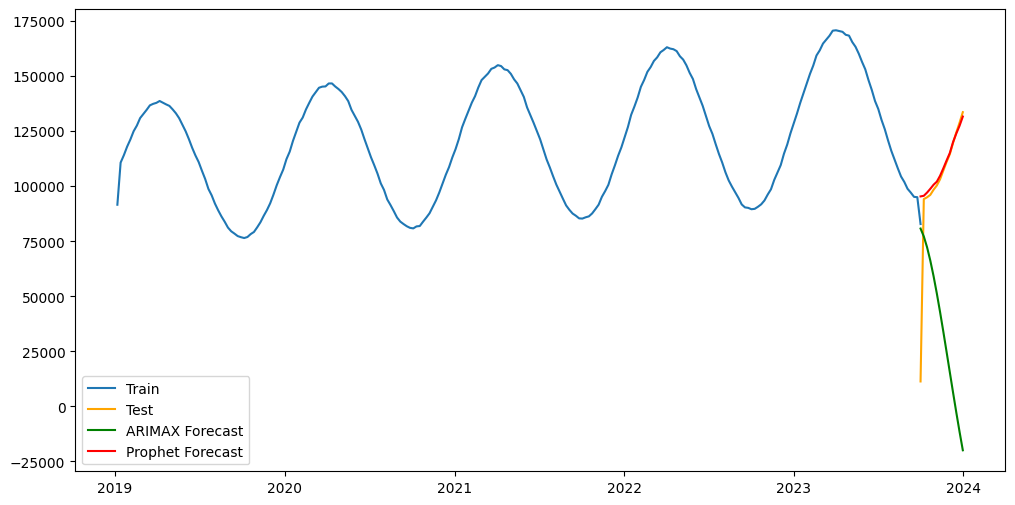

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train_series.index, train_series, label='Train')
plt.plot(test_series.index, test_series, label='Test', color='orange')
plt.plot(test_series.index, forecast_arimax, label='ARIMAX Forecast', color='green')
plt.plot(test_series.index, forecast_sales, label='Prophet Forecast', color='red')
plt.legend()
plt.show()

In [ ]:
# LSTM
train_data = pd.concat([train_series, train_exog], axis=1)
test_data  = pd.concat([test_series, test_exog], axis=1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

In [ ]:
import numpy as np

def create_sequences(data, seq_length=4):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length, :])   # features
        y.append(data[i+seq_length, 0])     # target = sales
    return np.array(X), np.array(y)

seq_length = 4  # use last 4 weeks
X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test   = create_sequences(test_scaled, seq_length)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(seq_length, train_scaled.shape[1])))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,473 (68.25 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=50, batch_size=8,
                    validation_split=0.1, verbose=1)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.1895 - val_loss: 0.1039
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0450 - val_loss: 0.0325
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0263 - val_loss: 0.0150
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0118 - val_loss: 0.0159
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0112 - val_loss: 0.0083
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0114 - val_loss: 0.0145
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0106 - val_loss: 0.0141
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0121 - val_loss: 0.0118
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0100 - val_loss: 0.0072
Epoch 10/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0105 - val_loss: 0.0037
Epoch 11/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0099 - val_loss: 0.0115
Epoch 12/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.008

In [ ]:
y_pred = model.predict(X_test)

# Inverse scale predictions
test_scaled_copy = test_scaled[seq_length:]  # align with y_test
inv_pred = np.zeros((len(y_pred), train_scaled.shape[1]))
inv_pred[:,0] = y_pred.flatten()
inv_pred[:,1:] = test_scaled_copy[:,1:]  # keep exogenous vars
forecast_lstm = scaler.inverse_transform(inv_pred)[:,0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np # Added this import to ensure np is available for sqrt

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred)/y_test)) * 100

print("LSTM RMSE:", rmse)
print("LSTM MAE:", mae)
print("LSTM MAPE:", mape)

LSTM RMSE: 0.09324931249330691
LSTM MAE: 0.07856730430530028
LSTM MAPE: 40.04947015936365


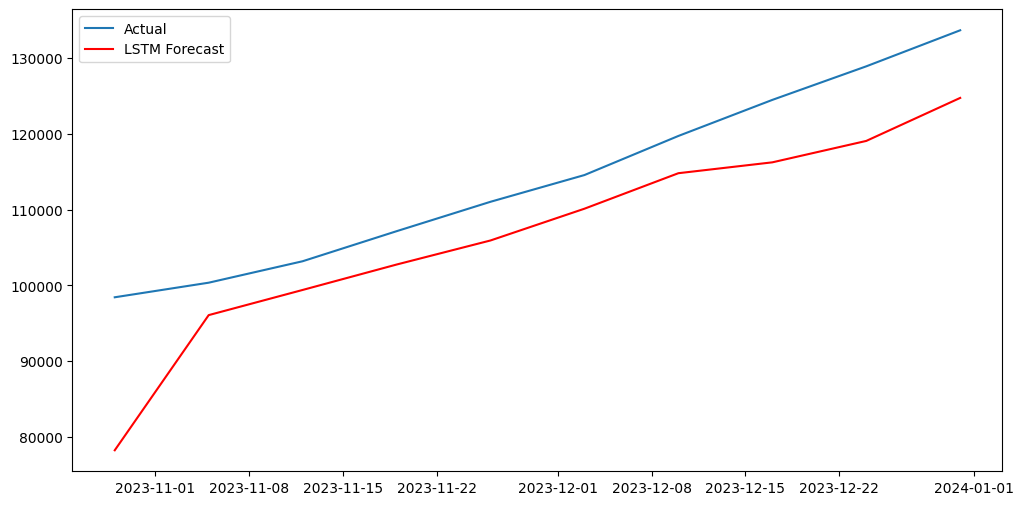

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test_series.index[seq_length:], test_series.values[seq_length:], label='Actual')
plt.plot(test_series.index[seq_length:], forecast_lstm, label='LSTM Forecast', color='red')
plt.legend()
plt.show()

In [ ]:
# XGBoost

def create_lag_features(df, lags=[1,2,3,4]):
    for lag in lags:
        df[f'sales_lag{lag}'] = df['sales'].shift(lag)
    return df

train_data = create_lag_features(train_data).dropna()
test_data  = create_lag_features(test_data).dropna()

In [ ]:
X_train = train_data.drop('sales', axis=1)
y_train = train_data['sales']

X_test = test_data.drop('sales', axis=1)
y_test = test_data['sales']

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05,
                         max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)

forecast_xgb = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mse_xgb  = mean_squared_error(y_test, forecast_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb  = mean_absolute_error(y_test, forecast_xgb)
mape_xgb = np.mean(np.abs((y_test - forecast_xgb)/y_test)) * 100

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAE:", mae_xgb)
print("XGBoost MAPE:", mape_xgb)

XGBoost RMSE: 1991.694630208155
XGBoost MAE: 1780.710205078125
XGBoost MAPE: 1.5829804643793175


In [ ]:
results = {
    "ARIMA/ARIMAX": {
        "RMSE": np.sqrt(mean_squared_error(test_series, forecast_arimax)),
        "MAE": mean_absolute_error(test_series, forecast_arimax),
        "MAPE": np.mean(np.abs((test_series - forecast_arimax)/test_series)) * 100
    },
    "Prophet": {
        "RMSE": np.sqrt(mean_squared_error(test_series, forecast_sales)),
        "MAE": mean_absolute_error(test_series, forecast_sales),
        "MAPE": np.mean(np.abs((test_series - forecast_sales)/test_series)) * 100
    },
    "LSTM": {
        "RMSE": np.sqrt(mean_squared_error(test_series[4:], forecast_lstm)),  # align with seq_length
        "MAE": mean_absolute_error(test_series[4:], forecast_lstm),
        "MAPE": np.mean(np.abs((test_series[4:] - forecast_lstm)/test_series[4:])) * 100
    },
    "XGBoost": {
        "RMSE": rmse_xgb,
        "MAE": mae_xgb,
        "MAPE": mape_xgb
    }
}

import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df)

                      RMSE           MAE       MAPE
ARIMA/ARIMAX  88260.489116  77182.646330  60.158672
Prophet       22515.730053   7321.146238  54.172887
LSTM           8799.751121   7414.239373   6.608381
XGBoost        1991.694630   1780.710205   1.582980


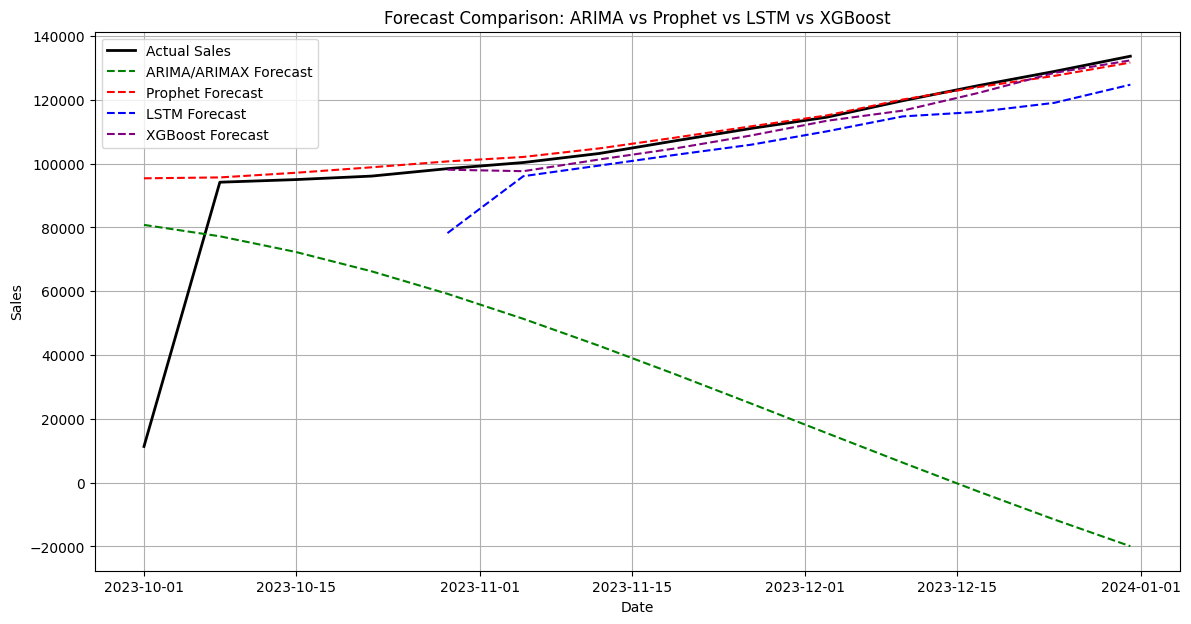

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

# Actual sales
plt.plot(test_series.index, test_series.values, label='Actual Sales', color='black', linewidth=2)

# ARIMA/ARIMAX forecast
plt.plot(test_series.index, forecast_arimax, label='ARIMA/ARIMAX Forecast', color='green', linestyle='--')

# Prophet forecast
plt.plot(test_series.index, forecast_sales, label='Prophet Forecast', color='red', linestyle='--')

# LSTM forecast (align with seq_length offset)
plt.plot(test_series.index[4:], forecast_lstm, label='LSTM Forecast', color='blue', linestyle='--')

# XGBoost forecast
plt.plot(test_series.index[-len(forecast_xgb):], forecast_xgb, label='XGBoost Forecast', color='purple', linestyle='--')

plt.title("Forecast Comparison: ARIMA vs Prophet vs LSTM vs XGBoost")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
forecast_df = pd.DataFrame(index=test_series.index)

forecast_df['Actual Sales'] = test_series
forecast_df['ARIMAX Forecast'] = forecast_arimax.reindex(test_series.index)
forecast_df['Prophet Forecast'] = pd.Series(forecast_sales, index=test_series.index)
forecast_df['LSTM Forecast'] = pd.Series(forecast_lstm, index=test_series.index[seq_length:])
forecast_df['XGBoost Forecast'] = pd.Series(forecast_xgb, index=test_series.index[seq_length:])

# Get weekly inventory and replenishment from the original 'test' DataFrame
forecast_df['Inventory'] = test['inventory'].resample('W').mean()
forecast_df['Replenishment'] = test['replenishment'].resample('W').sum()

forecast_df['Alert'] = (forecast_df['Prophet Forecast'] > forecast_df['Inventory']).astype(int)

forecast_df = forecast_df.reset_index().rename(columns={'index':'Date'})

forecast_df.to_csv("forecast_timeseries.csv", index=False)

In [ ]:
from google.colab import files
files.download("forecast_timeseries.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>